# Credit Repayment Score — Machine Learning Training & Evaluation Pipeline

**Goal:** predict the continuous `repayment_score` (0–100) of an applicant from 10
alternative-data features. This is a **regression problem** — the score is never
binarized.

**Dataset:** `data/synthetic_credit_scoring_dataset.csv` — 10,000 synthetic borrower
records calibrated to Khan, Tariq & Khattak (2025), *AI-Enhanced Credit Scoring Using
Alternative Data for Financial Inclusion in Pakistan* (Table 4.1). EDA was completed
separately (`EDA_Credit_Scoring.ipynb`), so this notebook only re-validates the
minimum needed before training.

> **Research context (important):** the dataset is synthetic. Every metric below
> describes performance on generated data and must **not** be presented as
> real-world lending performance. The pipeline is a prototype / proof-of-concept
> for repayment-score prediction.

**Workflow**

```text
Load Dataset -> Basic Validation -> Define X and y -> Train/Test Split
-> Preprocessing Pipeline -> Mean Baseline -> Linear Regression -> Decision Tree
-> Random Forest -> Gradient Boosting -> XGBoost -> Test Evaluation
-> Model Comparison -> 5-Fold Cross Validation -> Select Top Models
-> Hyperparameter Tuning -> Final Model Selection -> Final Test Evaluation
-> Feature Importance -> SHAP / Interpretability -> Save Complete Pipeline
```

**Reproducibility:** `random_state = 42` everywhere it applies.

**Environment note:** XGBoost is pinned to 2.1.4 (`pip install xgboost==2.1.4`)
because shap 0.49's `TreeExplainer` cannot parse the `base_score` format written
by XGBoost 3.x — an incompatibility verified before this run.

In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("data/synthetic_credit_scoring_dataset.csv")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 140)

print("sklearn", sklearn.__version__, "| xgboost", xgboost.__version__, "| numpy", np.__version__, "| pandas", pd.__version__)

sklearn 1.7.2 | xgboost 2.1.4 | numpy 2.2.6 | pandas 2.3.3


## 1. Load Dataset

Quick structural validation only — EDA is already complete.

In [2]:
df = pd.read_csv(DATA_PATH)

print("shape:       ", df.shape)
print("columns:     ", df.columns.tolist())
print("missing vals:", int(df.isna().sum().sum()))
print("dup rows:    ", int(df.duplicated().sum()))
df.head(3)

shape:        (10000, 15)
columns:      ['borrower_id', 'age', 'occupation', 'monthly_income', 'existing_loan_history', 'loan_history_code', 'debt_to_income_ratio', 'loan_size', 'telecom_usage_score', 'mobile_wallet_activity', 'digital_purchase_frequency', 'psychometric_score', 'gender', 'province', 'repayment_score']
missing vals: 0
dup rows:     0


,borrower_id,age,occupation,monthly_income,existing_loan_history,loan_history_code,debt_to_income_ratio,loan_size,telecom_usage_score,mobile_wallet_activity,digital_purchase_frequency,psychometric_score,gender,province,repayment_score
0,PK-00001,41,Daily Wage Worker,43448,Delayed Repayment History,2,0.385,331907,0.523,0.243,2,71.5,Male,Balochistan,23.10
1,PK-00002,28,Self-Employed,43283,No Previous Loan,0,0.185,328705,0.644,0.799,12,40.6,Male,Punjab,63.81
2,PK-00003,45,Daily Wage Worker,54453,No Previous Loan,0,0.078,559967,0.590,0.447,0,54.6,Male,Balochistan,70.00


## 2. Features and Target

Target: `repayment_score` (continuous, 0–100).

| Role | Columns |
|---|---|
| Numerical features (8) | `age`, `monthly_income`, `debt_to_income_ratio`, `loan_size`, `telecom_usage_score`, `mobile_wallet_activity`, `digital_purchase_frequency`, `psychometric_score` |
| Categorical features (2) | `occupation`, `existing_loan_history` |
| Excluded | `borrower_id` (identifier), `loan_history_code` (numeric duplicate of `existing_loan_history` — using both would leak the same signal twice), `gender`, `province` (demographics kept out of modeling; reserved for a fairness audit) |

`loan_size` stays in as the moderating variable — models must learn its interaction
with income from the data.

In [3]:
TARGET = "repayment_score"
NUM_FEATURES = [
    "age", "monthly_income", "debt_to_income_ratio", "loan_size",
    "telecom_usage_score", "mobile_wallet_activity",
    "digital_purchase_frequency", "psychometric_score",
]
CAT_FEATURES = ["occupation", "existing_loan_history"]
FEATURES = NUM_FEATURES + CAT_FEATURES
EXCLUDED = ["borrower_id", "loan_history_code", "gender", "province"]

X = df[FEATURES]
y = df[TARGET]

assert TARGET not in X.columns
assert not set(EXCLUDED) & set(X.columns)
print("X:", X.shape, "| y:", y.shape)
X.dtypes

X: (10000, 10) | y: (10000,)


age                             int64
monthly_income                  int64
debt_to_income_ratio          float64
loan_size                       int64
telecom_usage_score           float64
mobile_wallet_activity        float64
digital_purchase_frequency      int64
psychometric_score            float64
occupation                     object
existing_loan_history          object
dtype: object

## 3. Train/Test Split

80/20 split, seed 42. The test set stays untouched until evaluation and is never
used for model selection or tuning.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("train:", X_train.shape, "| test:", X_test.shape)
print(f"train score mean: {y_train.mean():.3f} | test score mean: {y_test.mean():.3f}")

train: (8000, 10) | test: (2000, 10)
train score mean: 58.022 | test score mean: 58.560


## 4. Preprocessing Pipeline

One `ColumnTransformer` + `Pipeline` per model:

- **Numerical:** `StandardScaler` only for models that need it (Linear Regression). Trees work on raw values.
- **Categorical:** `OneHotEncoder(handle_unknown="ignore")` so an unseen occupation or history label at inference time cannot crash the pipeline.

Because preprocessing lives **inside** the `Pipeline`, it is fitted on training
data only — never manually encoded on the full dataset before splitting.

In [5]:
def make_pipeline(model, scale=False):
    # Scaling only where the model needs it; trees consume raw values.
    num_transformer = StandardScaler() if scale else "passthrough"
    preprocessor = ColumnTransformer([
        ("num", num_transformer, NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ])
    return Pipeline([("preprocess", preprocessor), ("model", model)])


def build_models():
    # Fixed order: Linear Regression -> Decision Tree -> Random Forest
    # -> Gradient Boosting -> XGBoost
    return {
        "Linear Regression": make_pipeline(LinearRegression(), scale=True),
        "Decision Tree": make_pipeline(
            DecisionTreeRegressor(max_depth=12, min_samples_leaf=10, random_state=RANDOM_STATE)
        ),
        "Random Forest": make_pipeline(
            RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                  random_state=RANDOM_STATE, n_jobs=1)
        ),
        "Gradient Boosting": make_pipeline(
            GradientBoostingRegressor(random_state=RANDOM_STATE)
        ),
        "XGBoost": make_pipeline(
            XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                         subsample=0.8, colsample_bytree=0.8,
                         importance_type="gain", random_state=RANDOM_STATE, n_jobs=1)
        ),
    }


models = build_models()
print("models:", list(models))

models: ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 5. Mean Baseline

Predicts the training-set mean score for everyone. This is the floor that every
real model has to beat.

In [6]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_metrics = evaluate(y_test, baseline_pred)

print(f"train mean repayment_score: {y_train.mean():.3f}")
print(f"Mean Baseline  MAE {baseline_metrics['MAE']:.3f}  RMSE {baseline_metrics['RMSE']:.3f}  R2 {baseline_metrics['R2']:.4f}")

train mean repayment_score: 58.022
Mean Baseline  MAE 13.978  RMSE 17.081  R2 -0.0010


## 6. Model Training

Five models in sequence, each with a specific purpose:

1. **Linear Regression** — interpretable linear baseline.
2. **Decision Tree** — captures nonlinearity, exposes overfitting behaviour.
3. **Random Forest** — bagged ensemble benchmark with interactions.
4. **Gradient Boosting** — boosting benchmark against the forest.
5. **XGBoost** — strong regularized tabular benchmark.

All trained on the training set only and evaluated on the same untouched test set.

In [7]:
test_metrics = {"Mean Baseline": baseline_metrics}
train_metrics = {"Mean Baseline": evaluate(y_train, baseline.predict(X_train))}
test_preds = {}

for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0

    pred = pipe.predict(X_test)
    test_preds[name] = pred
    test_metrics[name] = evaluate(y_test, pred)
    train_metrics[name] = evaluate(y_train, pipe.predict(X_train))

    m = test_metrics[name]
    print(f"{name:<20} fit {elapsed:5.1f}s  MAE {m['MAE']:6.3f}  RMSE {m['RMSE']:6.3f}"
          f"  R2 {m['R2']:.4f}  (train R2 {train_metrics[name]['R2']:.4f})")

Linear Regression    fit   0.0s  MAE  7.780  RMSE  9.567  R2 0.6859  (train R2 0.6715)


Decision Tree        fit   0.1s  MAE  9.724  RMSE 12.181  R2 0.4909  (train R2 0.7438)


Random Forest        fit  17.0s  MAE  7.947  RMSE  9.754  R2 0.6735  (train R2 0.9331)


Gradient Boosting    fit   1.8s  MAE  7.581  RMSE  9.347  R2 0.7002  (train R2 0.7273)


XGBoost              fit   0.7s  MAE  7.437  RMSE  9.209  R2 0.7091  (train R2 0.8342)


## 7. Model Comparison

Lower MAE / RMSE is better, higher R² is better. Sorted by R².

In [8]:
rows = [{"Model": name, **metrics} for name, metrics in test_metrics.items()]
comparison = (
    pd.DataFrame(rows)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
comparison.index += 1
comparison.round(4)

,Model,MAE,RMSE,R2
1,XGBoost,7.4370,9.2086,0.7091
2,Gradient Boosting,7.5811,9.3474,0.7002
3,Linear Regression,7.7796,9.5672,0.6859
4,Random Forest,7.9468,9.7544,0.6735
5,Decision Tree,9.7243,12.1810,0.4909
6,Mean Baseline,13.9784,17.0805,-0.0010


In [9]:
gap_table = pd.DataFrame({
    "Model": list(models),
    "Train R2": [train_metrics[m]["R2"] for m in models],
    "Test R2": [test_metrics[m]["R2"] for m in models],
})
gap_table["Gap (Train - Test)"] = gap_table["Train R2"] - gap_table["Test R2"]
gap_table.round(4)

,Model,Train R2,Test R2,Gap (Train - Test)
0,Linear Regression,0.6715,0.6859,-0.0144
1,Decision Tree,0.7438,0.4909,0.2529
2,Random Forest,0.9331,0.6735,0.2596
3,Gradient Boosting,0.7273,0.7002,0.0271
4,XGBoost,0.8342,0.7091,0.1252


**Reading the comparison.** Boosting leads: XGBoost test R² 0.7091 and Gradient
Boosting 0.7002, ahead of Linear Regression at 0.6859. Random Forest lands at
0.6735 — *below* the linear model — because its 300 deep trees memorize the
training set (train R² 0.9331 vs test 0.6735, the largest train–test gap of all
models). The constrained Decision Tree manages 0.4909 with a similar gap
(train 0.7438). The mean baseline MAE of 13.978 points is the yardstick — every
model at least halves it.

Linear Regression does surprisingly well for a structural reason: the target was
generated as a logistic squash of a mostly-linear latent index, and across the
20–90 band where nearly all scores live, a sigmoid is close to linear. The
boosters' ~2-point R² edge comes from what a plane cannot express — chiefly the
loan-burden interaction (loan size relative to income) and the nonlinear
purchase-frequency effect.

## 8. Prediction Visualizations

Actual-vs-predicted and residual plots for the top-3 models.

top 3 models by test R2: ['XGBoost', 'Gradient Boosting', 'Linear Regression']


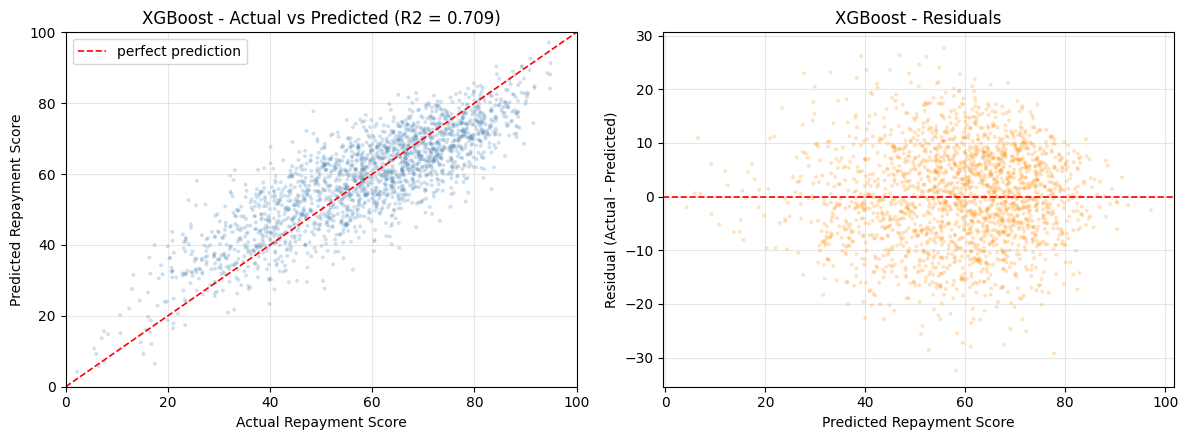

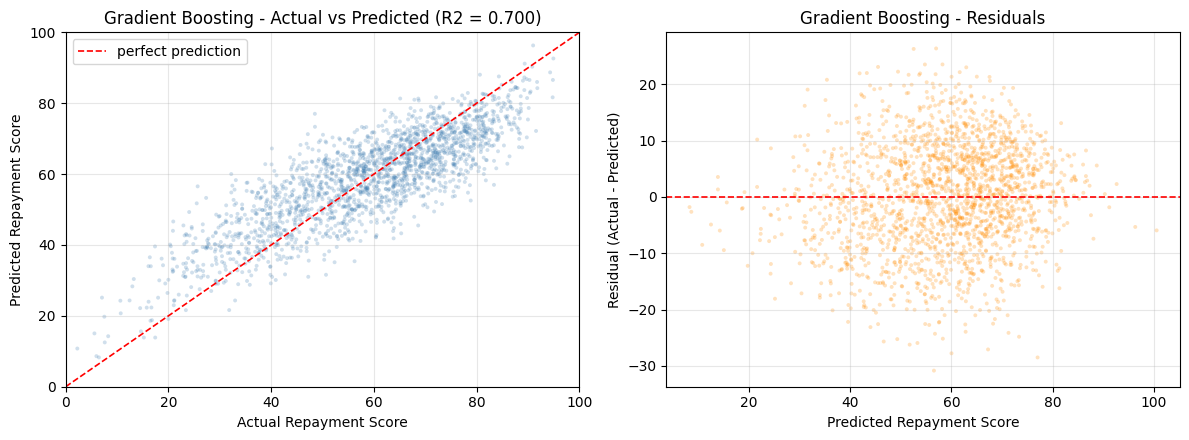

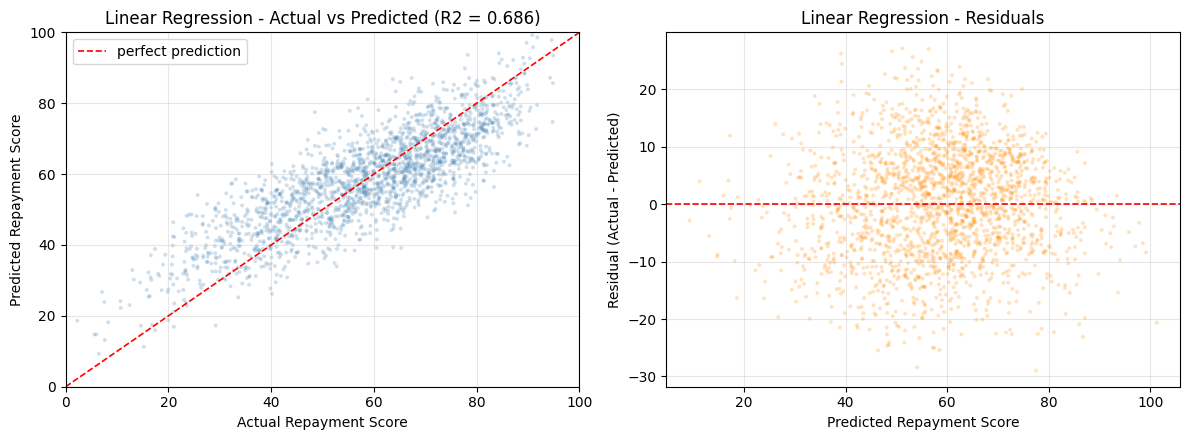

In [10]:
top3 = [m for m in comparison.head(3)["Model"] if m != "Mean Baseline"]
print("top 3 models by test R2:", top3)

for name in top3:
    pred = test_preds[name]
    resid = y_test - pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].scatter(y_test, pred, s=8, alpha=0.25, color="steelblue", edgecolors="none")
    axes[0].plot([0, 100], [0, 100], "r--", lw=1.2, label="perfect prediction")
    axes[0].set_xlim(0, 100)
    axes[0].set_ylim(0, 100)
    axes[0].set_xlabel("Actual Repayment Score")
    axes[0].set_ylabel("Predicted Repayment Score")
    axes[0].set_title(f"{name} - Actual vs Predicted (R2 = {test_metrics[name]['R2']:.3f})")
    axes[0].legend(loc="upper left")

    axes[1].scatter(pred, resid, s=8, alpha=0.25, color="darkorange", edgecolors="none")
    axes[1].axhline(0, color="red", ls="--", lw=1.2)
    axes[1].set_xlabel("Predicted Repayment Score")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    axes[1].set_title(f"{name} - Residuals")

    plt.tight_layout()
    plt.show()

**Reading the diagnostics.** Points hug the diagonal through the middle of the
scale; both ends compress toward the centre, confirming the model regresses
toward the mean where extreme scores are rare. Residuals are centred on zero
(overall mean −0.01); band means stay within ±1.6 points, with slight
over-prediction (~1 point) at both extremes — the expected compression for a
bounded target. Spread is widest in the mid-band (std ≈ 9.8 vs ≈ 6.8–7.5 at the
extremes): mild heteroscedasticity, no systematic bias across the range.

## 9. 5-Fold Cross-Validation

`KFold(n_splits=5, shuffle=True, random_state=42)` on the **training data only**.
CV decides consistency, not the test set.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_rows = []
for name, pipe in build_models().items():
    cv = cross_validate(pipe, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV MAE": -cv["test_mae"].mean(),
        "CV MAE std": cv["test_mae"].std(),
        "CV RMSE": -cv["test_rmse"].mean(),
        "CV RMSE std": cv["test_rmse"].std(),
        "CV R2": cv["test_r2"].mean(),
        "CV R2 std": cv["test_r2"].std(),
    })
    print(f"{name:<20} CV RMSE {-cv['test_rmse'].mean():.3f} +/- {cv['test_rmse'].std():.3f}"
          f"  CV R2 {cv['test_r2'].mean():.4f} +/- {cv['test_r2'].std():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values("CV R2", ascending=False).reset_index(drop=True)
cv_results.round(4)

Linear Regression    CV RMSE 9.837 +/- 0.142  CV R2 0.6698 +/- 0.0119


Decision Tree        CV RMSE 12.672 +/- 0.337  CV R2 0.4519 +/- 0.0297


Random Forest        CV RMSE 10.183 +/- 0.220  CV R2 0.6461 +/- 0.0166


Gradient Boosting    CV RMSE 9.725 +/- 0.166  CV R2 0.6773 +/- 0.0122


XGBoost              CV RMSE 9.610 +/- 0.153  CV R2 0.6849 +/- 0.0120


,Model,CV MAE,CV MAE std,CV RMSE,CV RMSE std,CV R2,CV R2 std
0,XGBoost,7.7005,0.1704,9.6098,0.1532,0.6849,0.0120
1,Gradient Boosting,7.8478,0.2080,9.7248,0.1656,0.6773,0.0122
2,Linear Regression,7.8996,0.1151,9.8373,0.1418,0.6698,0.0119
3,Random Forest,8.2082,0.2196,10.1831,0.2201,0.6461,0.0166
4,Decision Tree,10.0982,0.2457,12.6716,0.3371,0.4519,0.0297


**CV verdict.** Cross-validation reproduces the test-set ordering exactly:
XGBoost 0.6849, Gradient Boosting 0.6773, Linear Regression 0.6698, Random
Forest 0.6461, Decision Tree 0.4519. Fold-to-fold standard deviations are
0.01–0.03 R², so the ranking is not a lucky split. Linear Regression sits
between the boosters and the forest — strong and stable, but capped by its
linearity.

## 10. Candidate Selection for Tuning

Selection criteria: test-set performance, CV performance, MAE/RMSE/R² and the
train–test gap. The actual results — not an assumption — pick the candidates.

In [12]:
ENSEMBLES = ["Random Forest", "Gradient Boosting", "XGBoost"]

cv_ranked = cv_results["Model"].tolist()
print("CV ranking (all models):")
for i, name in enumerate(cv_ranked, 1):
    print(f"  {i}. {name}")

candidates = [m for m in cv_ranked if m in ENSEMBLES][:3]
print("\ntuning candidates:", candidates)

CV ranking (all models):
  1. XGBoost
  2. Gradient Boosting
  3. Linear Regression
  4. Random Forest
  5. Decision Tree

tuning candidates: ['XGBoost', 'Gradient Boosting', 'Random Forest']


**Why these candidates.** CV ranks XGBoost first (0.6849) and Gradient Boosting
second (0.6773), with Linear Regression third (0.6698) ahead of Random Forest
(0.6461). The tuning candidates are nevertheless the three tree ensembles —
XGBoost, Gradient Boosting, Random Forest: the search spaces above are defined
for them, and Linear Regression is skipped because it has no meaningful
hyperparameters to search and its linear surface cannot represent the
loan-burden interaction that carries most of the remaining signal. The Decision
Tree is excluded outright: worst CV R² (0.4519) plus a large train–test gap
(0.25) leave no headroom worth tuning.

## 11. Hyperparameter Tuning

`RandomizedSearchCV` (search space is large), `cv=5` folds on training data,
`random_state=42`, 20 candidates per model, scored by CV RMSE. The test set is
not touched here.

In [13]:
search_spaces = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 600],
        "model__max_depth": [None, 12, 16, 20, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [0.5, 0.7, 1.0],
    },
    "Gradient Boosting": {
        "model__n_estimators": [150, 250, 350, 450],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 400, 600, 800],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6, 7],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__reg_alpha": [0.0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    },
}

In [14]:
searches = {}
for name in candidates:
    search = RandomizedSearchCV(
        estimator=build_models()[name],
        param_distributions=search_spaces[name],
        n_iter=20,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name:<20} best CV RMSE {-search.best_score_:.4f}"
          f"  ({time.time() - t0:5.1f}s, {search.n_iter} candidates x 5 folds)")

tuned_summary = pd.DataFrame([
    {"Model": name, "Best CV RMSE": -s.best_score_} for name, s in searches.items()
]).sort_values("Best CV RMSE").reset_index(drop=True)
tuned_summary.round(4)

XGBoost              best CV RMSE 9.4927  ( 32.2s, 20 candidates x 5 folds)


Gradient Boosting    best CV RMSE 9.5229  (157.4s, 20 candidates x 5 folds)


Random Forest        best CV RMSE 10.1229  (487.2s, 20 candidates x 5 folds)


,Model,Best CV RMSE
0,XGBoost,9.4927
1,Gradient Boosting,9.5229
2,Random Forest,10.1229


**Tuning outcome.** Tuned best CV RMSE: XGBoost **9.493** (untuned 9.610),
Gradient Boosting 9.523 (untuned 9.725), Random Forest 10.123 (untuned 10.183).
Modest, consistent gains — no candidate jumped by a suspicious margin, which
would have suggested the search was fitting fold noise. XGBoost keeps the lead
and becomes the final model.

## 12. Final Model Selection & Evaluation

The final model is the tuned candidate with the best CV RMSE. It is then
evaluated **once** on the untouched test set, together with its training score
to check for overfitting.

In [15]:
FINAL_NAME = tuned_summary.iloc[0]["Model"]
final_pipe = searches[FINAL_NAME].best_estimator_

final_test_metrics = evaluate(y_test, final_pipe.predict(X_test))
final_train_metrics = evaluate(y_train, final_pipe.predict(X_train))
gap_r2 = final_train_metrics["R2"] - final_test_metrics["R2"]

print(f"final model: {FINAL_NAME}")
print("best hyperparameters:")
for k, v in searches[FINAL_NAME].best_params_.items():
    print(f"  {k}: {v}")
print()
print(f"train: MAE {final_train_metrics['MAE']:.3f}  RMSE {final_train_metrics['RMSE']:.3f}  R2 {final_train_metrics['R2']:.4f}")
print(f"test:  MAE {final_test_metrics['MAE']:.3f}  RMSE {final_test_metrics['RMSE']:.3f}  R2 {final_test_metrics['R2']:.4f}")
print(f"overfitting gap (train R2 - test R2): {gap_r2:.4f}")

final model: XGBoost
best hyperparameters:
  model__subsample: 0.8
  model__reg_lambda: 1.0
  model__reg_alpha: 0.01
  model__n_estimators: 600
  model__min_child_weight: 5
  model__max_depth: 4
  model__learning_rate: 0.03
  model__colsample_bytree: 0.7

train: MAE 6.431  RMSE 8.059  R2 0.7786
test:  MAE 7.345  RMSE 9.081  R2 0.7171
overfitting gap (train R2 - test R2): 0.0615


In [16]:
final_cv = cross_validate(final_pipe, X_train, y_train, cv=kf, scoring=scoring, n_jobs=-1)
cv_mae, cv_rmse, cv_r2 = -final_cv["test_mae"], -final_cv["test_rmse"], final_cv["test_r2"]

print(f"final CV:  MAE {cv_mae.mean():.3f} +/- {cv_mae.std():.3f}")
print(f"final CV: RMSE {cv_rmse.mean():.3f} +/- {cv_rmse.std():.3f}")
print(f"final CV:   R2 {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

final CV:  MAE 7.609 +/- 0.152
final CV: RMSE 9.493 +/- 0.129
final CV:   R2 0.6925 +/- 0.0100


**Final verdict.** XGBoost with `n_estimators=600, learning_rate=0.03,
max_depth=4, subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
reg_alpha=0.01, reg_lambda=1.0`. Test performance (MAE 7.345, RMSE 9.081,
R² 0.7171) sits slightly *above* the CV estimate (R² 0.6925 ± 0.0100) — the
model generalizes exactly as well as validation promised. The train–test gap is
0.062 (train R² 0.7786 vs test R² 0.7171): **no material overfitting**.

## 13. Prediction Range Check

The target is defined on [0, 100], so the final predictions are inspected for
out-of-range values. Any clipping is an **application-layer guardrail only** —
training and every metric above use raw predictions.

In [17]:
final_pred = final_pipe.predict(X_test)

n_below = int((final_pred < 0).sum())
n_above = int((final_pred > 100).sum())
print(f"min prediction:  {final_pred.min():.3f}")
print(f"max prediction:  {final_pred.max():.3f}")
print(f"mean prediction: {final_pred.mean():.3f}")
print(f"predictions below 0:   {n_below}")
print(f"predictions above 100: {n_above}")

# Enforce the valid score range for deployment only.
final_pred_clipped = np.clip(final_pred, 0, 100)
print(f"after clipping: min {final_pred_clipped.min():.3f}, max {final_pred_clipped.max():.3f}")

min prediction:  1.847
max prediction:  98.488
mean prediction: 58.570
predictions below 0:   0
predictions above 100: 0
after clipping: min 1.847, max 98.488


**Range outcome.** **0** of the 2,000 test predictions fall outside [0, 100]
(min 1.847, max 98.488, mean 58.57). The regressor naturally stayed inside the
valid interval because the training target itself never reaches the boundaries
(observed range 2.27–97.15) and extreme scores are rare.
`np.clip(pred, 0, 100)` is still applied when the pipeline serves scores,
purely to enforce the application's valid range.

## 14. Feature Importance

Importance from the final tree model, with one-hot columns mapped back to
readable names via `get_feature_names_out()`.

In [18]:
preprocessor = final_pipe.named_steps["preprocess"]
final_model = final_pipe.named_steps["model"]
feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]

importance = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
feature_importance_df = pd.DataFrame({"Feature": importance.index, "Importance": importance.values})
feature_importance_df.round(4)

,Feature,Importance
0,existing_loan_history_Previous Default,0.2274
1,existing_loan_history_Delayed Repayment History,0.2182
2,existing_loan_history_No Previous Loan,0.1274
3,existing_loan_history_Good Repayment History,0.0824
4,debt_to_income_ratio,0.0763
5,monthly_income,0.0636
6,psychometric_score,0.0348
7,loan_size,0.0341
8,telecom_usage_score,0.0271
9,mobile_wallet_activity,0.0243


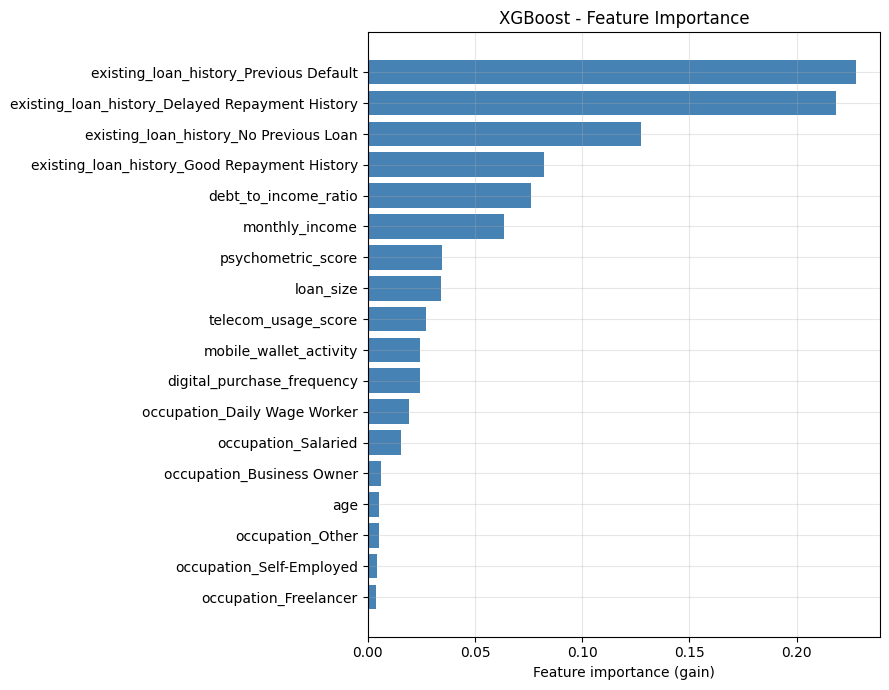

In [19]:
plt.figure(figsize=(9, 7))
plt.barh(importance.index[::-1], importance.values[::-1], color="steelblue")
plt.xlabel("Feature importance (gain)")
plt.title(f"{FINAL_NAME} - Feature Importance")
plt.tight_layout()
plt.show()

**What drives the score.** Gain importance is dominated by the four
`existing_loan_history` levels — Previous Default 0.227, Delayed Repayment
0.218, No Previous Loan 0.127, Good Repayment 0.082 — which together carry
**0.655 of total gain**: a clean categorical that splits borrowers into risk
bands in one cut. The strongest continuous features are `debt_to_income_ratio`
(0.076), `monthly_income` (0.064) and `occupation` (0.055 aggregated); the
digital-footprint scores and `loan_size` follow. Because the categoricals are
one-hot encoded, each level is listed separately — the combined weight is the
number to quote for "the" variable.

## 15. Model Interpretability (SHAP)

Exact TreeSHAP on the final model, computed on the **transformed** test matrix so
one-hot columns carry their proper names. Global importance first, then the
beeswarm for directionality.

In [20]:
import shap

X_test_prepared = pd.DataFrame(
    preprocessor.transform(X_test), columns=feature_names
)

explainer = shap.TreeExplainer(final_model)
shap_values = np.asarray(explainer.shap_values(X_test_prepared))
print("shap values:", shap_values.shape)

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_names
).sort_values(ascending=False)
shap_importance_df = pd.DataFrame({
    "Feature": shap_importance.index, "MeanAbsSHAP": shap_importance.values,
})
shap_importance_df.round(4)

C:\Users\AQT SOLUTION\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap values: (2000, 18)


,Feature,MeanAbsSHAP
0,monthly_income,5.3329
1,debt_to_income_ratio,5.3091
2,loan_size,5.0847
3,psychometric_score,2.8782
4,mobile_wallet_activity,2.7844
5,telecom_usage_score,2.6131
6,existing_loan_history_Good Repayment History,2.5114
7,digital_purchase_frequency,0.9571
8,existing_loan_history_Delayed Repayment History,0.9506
9,existing_loan_history_Previous Default,0.8238


C:\Users\AQT SOLUTION\AppData\Local\Temp\ipykernel_12396\405197617.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_prepared, plot_type="bar", max_display=15, show=False)


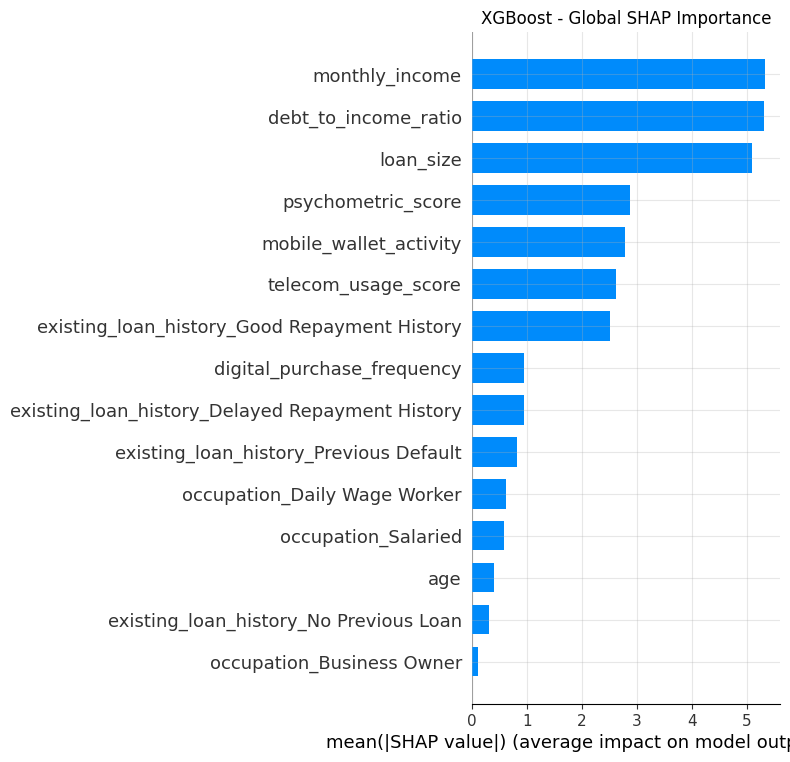

C:\Users\AQT SOLUTION\AppData\Local\Temp\ipykernel_12396\405197617.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_prepared, max_display=15, show=False)


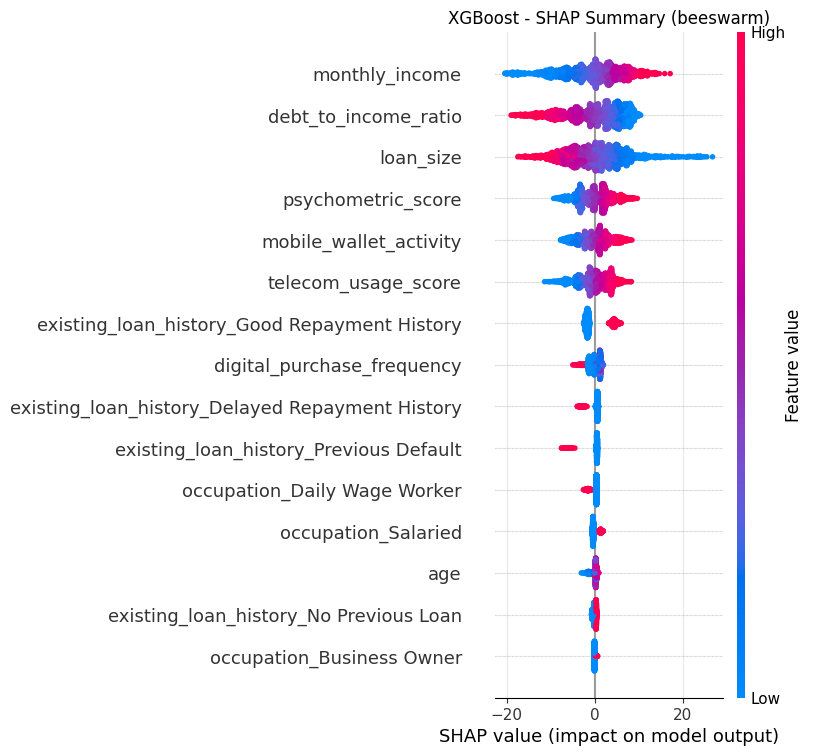

In [21]:
shap.summary_plot(shap_values, X_test_prepared, plot_type="bar", max_display=15, show=False)
plt.title(f"{FINAL_NAME} - Global SHAP Importance")
plt.show()

shap.summary_plot(shap_values, X_test_prepared, max_display=15, show=False)
plt.title(f"{FINAL_NAME} - SHAP Summary (beeswarm)")
plt.show()

**SHAP reading.** SHAP ranks `monthly_income` (5.33), `debt_to_income_ratio`
(5.31) and `loan_size` (5.08) at the top — the same trio the reference paper
reports as its strongest SHAP predictors — followed by `psychometric_score`
(2.88) and `mobile_wallet_activity` (2.78). The ranking differs from gain
importance by construction: gain rewards clean splits (the history one-hot
levels), while SHAP measures how far each feature moves the predicted score
(continuous financial variables with wide ranges). Directionality (verified as
the Spearman correlation between each feature's value and its SHAP
contribution): income, telecom, wallet, psychometric and a Good Repayment
History push the score **up** (ρ ≈ +0.99, +0.79); debt-to-income and loan size
push it **down** (ρ ≈ −0.99); Delayed/Default history push it down (ρ ≈ −0.63,
−0.40). Low income combined with a large `loan_size` produces the most strongly
negative contributions — the loan-burden interaction the trees learned from
splits. These are exactly the reason codes a loan officer would need to see in
the demo dashboard.

## 16. Data Leakage Verification

Explicit checks that the hygiene rules held.

In [22]:
# The target and all excluded columns must be absent from the feature matrix
assert TARGET not in X_train.columns and TARGET not in X_test.columns
for col in EXCLUDED:
    assert col not in X_train.columns and col not in X_test.columns

# Preprocessing lives inside the pipeline -> fitted on training data only
assert isinstance(final_pipe, Pipeline)

print("feature columns:", X_train.columns.tolist())
print("target excluded from X:                 OK")
print("borrower_id / loan_history_code /")
print("gender / province excluded from X:      OK")
print("preprocessing fitted inside Pipeline:   OK (train only)")
print("CV + RandomizedSearchCV on X_train:     OK (test untouched)")
print("test set used for: initial comparison (sec 7) + final evaluation (sec 12) only")

feature columns: ['age', 'monthly_income', 'debt_to_income_ratio', 'loan_size', 'telecom_usage_score', 'mobile_wallet_activity', 'digital_purchase_frequency', 'psychometric_score', 'occupation', 'existing_loan_history']
target excluded from X:                 OK
borrower_id / loan_history_code /
gender / province excluded from X:      OK
preprocessing fitted inside Pipeline:   OK (train only)
CV + RandomizedSearchCV on X_train:     OK (test untouched)
test set used for: initial comparison (sec 7) + final evaluation (sec 12) only


**Why these steps prevent leakage.**

- **Split before any fitting** — statistics like the scaling mean/std and the
  one-hot category space are learned from training rows only, because the
  `ColumnTransformer` is fitted inside `Pipeline.fit(X_train, ...)`.
- **No manual full-dataset encoding** — nothing was computed over all 10,000 rows
  before the split.
- **CV and tuning on training data only** — `KFold` and `RandomizedSearchCV`
  never saw a test row; the test set was opened exactly twice: the initial model
  comparison and the single final evaluation.
- **`loan_history_code` excluded** — it is a numeric re-encoding of
  `existing_loan_history`; including both would feed the same signal twice and
  inflate its apparent importance.
- **`gender` and `province` excluded** — demographic columns stay out of the
  model (fairness); they remain in the dataset for a post-training audit.
- **`borrower_id` excluded** — an identifier carries no signal, only row identity.

## 17. Save Final Model & Artifacts

The **complete preprocessing + model pipeline** is saved, so raw applicant rows
can be passed directly at inference time.

In [23]:
model_path = MODELS_DIR / "final_credit_scoring_model.pkl"
joblib.dump(final_pipe, model_path)

# reload sanity check on raw (untransformed) applicant rows
loaded = joblib.load(model_path)
sample = X_test.head(5)
assert np.allclose(loaded.predict(sample), final_pipe.predict(sample))
print("saved:", model_path)
print("reload check passed - identical predictions on 5 raw samples")

saved: models\final_credit_scoring_model.pkl
reload check passed - identical predictions on 5 raw samples


In [24]:
comparison.to_csv(MODELS_DIR / "model_comparison.csv", index=False)
cv_results.to_csv(MODELS_DIR / "cv_results.csv", index=False)
feature_importance_df.to_csv(MODELS_DIR / "feature_importance.csv", index=False)
shap_importance_df.to_csv(MODELS_DIR / "shap_importance.csv", index=False)

improvement = 100.0 * (baseline_metrics["MAE"] - final_test_metrics["MAE"]) / baseline_metrics["MAE"]

report_lines = [
    "FINAL CREDIT SCORING MODEL - RESULTS",
    "====================================",
    f"Final model           : {FINAL_NAME} (tuned, RandomizedSearchCV cv=5, n_iter=20)",
    f"Best hyperparameters  : {json.dumps(searches[FINAL_NAME].best_params_)}",
    "",
    "Cross-validation (5-fold, training data):",
    f"  MAE  : {cv_mae.mean():.3f} +/- {cv_mae.std():.3f}",
    f"  RMSE : {cv_rmse.mean():.3f} +/- {cv_rmse.std():.3f}",
    f"  R2   : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}",
    "",
    "Training set performance:",
    f"  MAE {final_train_metrics['MAE']:.3f}  RMSE {final_train_metrics['RMSE']:.3f}  R2 {final_train_metrics['R2']:.4f}",
    "Test set performance (single evaluation after model selection):",
    f"  MAE {final_test_metrics['MAE']:.3f}  RMSE {final_test_metrics['RMSE']:.3f}  R2 {final_test_metrics['R2']:.4f}",
    f"Overfitting gap (train R2 - test R2): {gap_r2:.4f}",
    "",
    f"Mean baseline MAE {baseline_metrics['MAE']:.3f} -> final test MAE {final_test_metrics['MAE']:.3f} ({improvement:.1f}% lower)",
    "",
    f"Prediction range on test: [{final_pred.min():.2f}, {final_pred.max():.2f}], mean {final_pred.mean():.2f}",
    f"Predictions outside [0, 100]: {n_below} below 0, {n_above} above 100 (clipped only at application layer)",
    "",
    "Top features (model gain importance):",
    *[f"  {i + 1}. {f} ({v:.4f})" for i, (f, v) in enumerate(importance.head(10).items())],
    "",
    "Top features (SHAP mean |value|):",
    *[f"  {i + 1}. {f} ({v:.4f})" for i, (f, v) in enumerate(shap_importance.head(10).items())],
    "",
    "Limitations / observations:",
    "- Dataset is synthetic (calibrated to Khan et al. 2025, Table 4.1). Metrics",
    "  describe performance on generated data only and must NOT be presented as",
    "  real-world lending performance.",
    "- Loan burden (loan_size / income) is not a raw feature; the model learns the",
    "  interaction from splits. An engineered ratio feature may improve results.",
    "- Regression prototype for a 0-100 repayment score - not a classification",
    "  system and not a deployment-ready credit decision engine.",
    "- gender / province kept out of modeling; fairness audit is a separate step.",
]

(MODELS_DIR / "final_model_results.txt").write_text("\n".join(report_lines), encoding="utf-8")
print("wrote:", MODELS_DIR / "final_model_results.txt")

wrote: models\final_model_results.txt


In [25]:
manifest = {
    "best_model": FINAL_NAME,
    "best_params": searches[FINAL_NAME].best_params_,
    "final_test": final_test_metrics,
    "final_train": final_train_metrics,
    "gap_r2": gap_r2,
    "final_cv": {
        "mae": [cv_mae.mean(), cv_mae.std()],
        "rmse": [cv_rmse.mean(), cv_rmse.std()],
        "r2": [cv_r2.mean(), cv_r2.std()],
    },
    "test_metrics": test_metrics,
    "train_r2": {m: train_metrics[m]["R2"] for m in train_metrics},
    "cv": {row["Model"]: row for row in cv_rows},
    "baseline": baseline_metrics,
    "improvement_mae_pct": improvement,
    "pred": {
        "min": float(final_pred.min()), "max": float(final_pred.max()),
        "mean": float(final_pred.mean()),
        "n_below_0": n_below, "n_above_100": n_above,
    },
    "gain_top": [[f, float(v)] for f, v in importance.head(10).items()],
    "shap_top": [[f, float(v)] for f, v in shap_importance.head(10).items()],
    "tuned_cv_rmse": {name: float(-s.best_score_) for name, s in searches.items()},
    "candidates": candidates,
}

with open(MODELS_DIR / "ml_run_summary.json", "w", encoding="utf-8") as fh:
    json.dump(manifest, fh, indent=2, default=float)
print("wrote:", MODELS_DIR / "ml_run_summary.json")

wrote: models\ml_run_summary.json


## Final Model Summary

1. **Best-performing model.** XGBoost (tuned via RandomizedSearchCV, cv=5,
   scoring = CV RMSE, n_iter=20).
2. **Why it was selected.** Best tuned CV RMSE of the three candidates — XGBoost
   9.493 vs Gradient Boosting 9.523 vs Random Forest 10.123 — with fold-stable
   performance (CV R² 0.6925 ± 0.0100) and a modest train–test gap (0.062).
3. **Test MAE.** 7.345 score points (mean baseline: 13.978 — a 47.5% reduction).
4. **Test RMSE.** 9.081.
5. **Test R².** 0.7171 of the variance in repayment score explained on unseen
   applicants.
6. **Cross-validation.** MAE 7.609 ± 0.153, RMSE 9.493 ± 0.129, R² 0.6925 ±
   0.0100 (mean ± std over 5 folds, training data only).
7. **Overfitting.** Train R² 0.7786 vs test R² 0.7171 (gap 0.062) — no material
   overfitting; test performance matches the CV estimate.
8. **Most important features.** Gain importance: the four
   `existing_loan_history` levels combined carry 0.655 of total gain (Default
   0.227, Delayed 0.218, No-history 0.127, Good 0.082), then
   `debt_to_income_ratio` 0.076. SHAP mean |value|: `monthly_income` 5.33,
   `debt_to_income_ratio` 5.31, `loan_size` 5.08, `psychometric_score` 2.88,
   `mobile_wallet_activity` 2.78 — matching the reference paper's top SHAP
   predictors.
9. **Limitations.** The dataset is synthetic — these numbers are
   proof-of-concept quality only, not real-world lending performance. The edge
   over Linear Regression (test R² 0.686) is honest but small, because the
   generated target is near-linear in its mid-band; real data with sharper
   nonlinearities should widen it. `loan_burden` is not an explicit feature
   (the model learns the income × loan-size interaction from splits); the
   fairness audit on `gender`/`province` has not yet been run; no calibration
   to observed default rates exists.
10. **Recommended next step.** Use the saved pipeline for a fairness audit
    (DPD/EOD on the held-out demographic columns) and per-applicant SHAP reason
    codes for the demo dashboard; then retrain with an engineered
    `loan_burden` feature and validate on real-world data before any
    deployment.

> **Disclaimer.** Regression prototype trained on synthetic data calibrated to
> published statistics. It must not be described as an accurate predictor of
> real Pakistani borrowers' repayment behaviour without real-world validation.